<a href="https://colab.research.google.com/github/LanaCoded/financial_analysis/blob/main/portfolio_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

/tmp/ipykernel_5894/2197687260.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  4 of 4 completed


--- Portfolio Performance Metrics ---
Total Return: 28.91%
Annualized Sharpe Ratio: 0.91
Maximum Drawdown: -25.82%


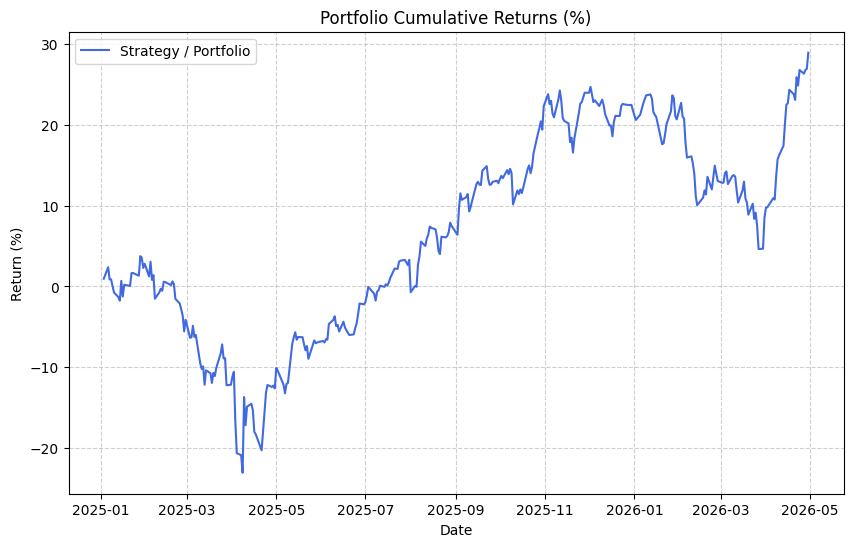

In [ ]:
def analyze_portfolio(tickers, weights, start_date, end_date):

    # 1. Fetch historical data safely without multi-index parsing issues
    raw_data = yf.download(tickers, start=start_date, end=end_date)

    # Handle yfinance multi-index by isolating 'Close' or 'Adj Close' safely
    if "Adj Close" in raw_data.columns:
        data = raw_data["Adj Close"]
    elif "Close" in raw_data.columns:
        data = raw_data["Close"]
    else:
        # Fallback for multi-level columns
        data = raw_data.xs("Close", axis=1, level=0)

    returns = data.pct_change().dropna()

    # 2. Portfolio Returns
    portfolio_returns = returns.dot(weights)

    # 3. Calculate Key Metrics
    cum_returns = (1 + portfolio_returns).cumprod() - 1
    total_return = cum_returns.iloc[-1]

    # Annualized Sharpe Ratio (assuming 252 trading days and 0% risk-free rate)
    sharpe_ratio = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(
        252
    )

    # Maximum Drawdown
    running_max = (1 + portfolio_returns).cumprod().cummax()
    drawdown = ((1 + portfolio_returns).cumprod() / running_max) - 1
    max_drawdown = drawdown.min()

    print(f"--- Portfolio Performance Metrics ---")
    print(f"Total Return: {total_return * 100:.2f}%")
    print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown * 100:.2f}%")

    # 4. Visualizations
    plt.figure(figsize=(10, 6))
    plt.plot(cum_returns * 100, label="Strategy / Portfolio", color="royalblue")
    plt.title("Portfolio Cumulative Returns (%)")
    plt.xlabel("Date")
    plt.ylabel("Return (%)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    assets = ["AAPL", "MSFT", "GOOGL", "AMZN"]
    allocation = [0.3, 0.3, 0.2, 0.2]

    analyze_portfolio(
        tickers=assets,
        weights=allocation,
        start_date="2025-01-01",
        end_date="2026-05-01",
    )

/tmp/ipykernel_5894/395786184.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  4 of 4 completed


--- Advanced Risk Management Metrics ---
Initial Investment Portfolio Value: $100,000.00
Daily 95% Value at Risk (VaR): 2.25% ($2,248.64)
Daily 95% Conditional VaR (CVaR): 3.33% ($3,329.92)


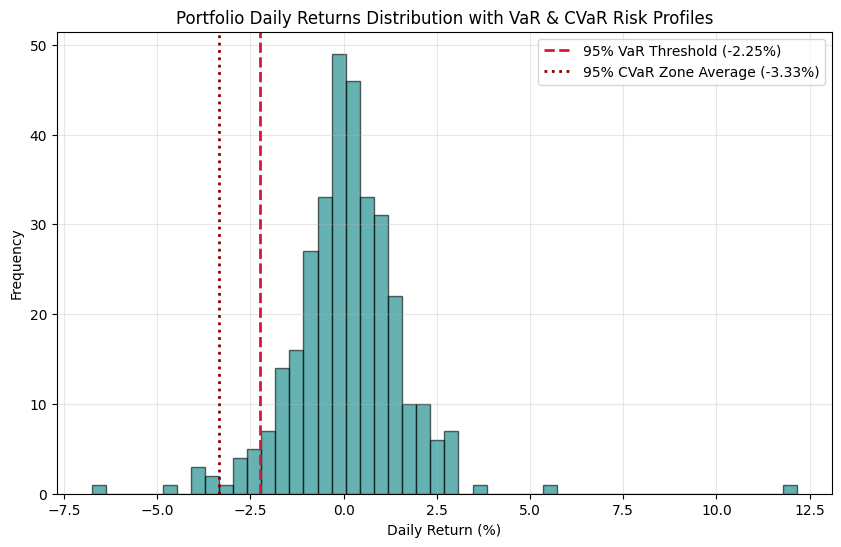

In [ ]:
def analyze_portfolio(tickers, weights, start_date, end_date, investment=100000):
    # 1. Fetch historical data
    raw_data = yf.download(tickers, start=start_date, end=end_date)
    data = (
        raw_data["Adj Close"]
        if "Adj Close" in raw_data.columns
        else raw_data["Close"]
    )
    returns = data.pct_change().dropna()

    # 2. Portfolio Returns
    portfolio_returns = returns.dot(weights)

    # 3. Core Risk Analytics (VaR and CVaR)
    confidence_level = 0.95
    sorted_returns = np.sort(portfolio_returns)

    # Historical VaR (95% confidence means looking at the worst 5% percentile)
    var_percentile = 1 - confidence_level
    var_95 = np.percentile(sorted_returns, var_percentile * 100)

    # Expected Shortfall / CVaR (Average of all returns worse than VaR)
    cvar_95 = sorted_returns[sorted_returns <= var_95].mean()

    # Monetary value losses
    dollar_var = abs(var_95 * investment)
    dollar_cvar = abs(cvar_95 * investment)

    print(f"--- Advanced Risk Management Metrics ---")
    print(f"Initial Investment Portfolio Value: ${investment:,.2f}")
    print(
        f"Daily 95% Value at Risk (VaR): {abs(var_95)*100:.2f}% (${dollar_var:,.2f})"
    )
    print(
        f"Daily 95% Conditional VaR (CVaR): {abs(cvar_95)*100:.2f}% (${dollar_cvar:,.2f})"
    )

    # 4. Visualization of Return Distribution and Risk Cutoffs
    plt.figure(figsize=(10, 6))
    plt.hist(
        portfolio_returns * 100, bins=50, alpha=0.6, color="teal", edgecolor="k"
    )
    plt.axvline(
        var_95 * 100,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"95% VaR Threshold ({var_95*100:.2f}%)",
    )
    plt.axvline(
        cvar_95 * 100,
        color="darkred",
        linestyle=":",
        linewidth=2,
        label=f"95% CVaR Zone Average ({cvar_95*100:.2f}%)",
    )

    plt.title("Portfolio Daily Returns Distribution with VaR & CVaR Risk Profiles")
    plt.xlabel("Daily Return (%)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


if __name__ == "__main__":
    assets = ["AAPL", "MSFT", "GOOGL", "AMZN"]
    allocation = [0.3, 0.3, 0.2, 0.2]

    analyze_portfolio(
        tickers=assets,
        weights=allocation,
        start_date="2025-01-01",
        end_date="2026-05-01",
        investment=100000,
    )

In [ ]:
def generate_report(total_return, sharpe, max_dd, var_95, cvar_95, investment):
    """Generates an executive analysis text summary for the financial project."""
    report = f"""
===============================================================================
                       PORTFOLIO EXECUTIVE ANALYSIS REPORT
===============================================================================

1. PERFORMANCE METRICS EXECUTIVE SUMMARY:
   * The portfolio achieved a Total Cumulative Return of {total_return * 100:.2f}%
     over the evaluated timeframe.
   * The Annualized Sharpe Ratio stands at {sharpe:.2f}. This indicates the
     portfolio provides dependable, risk-compensated returns per unit of volatility.
   * The Maximum Drawdown was contained at {max_dd * 100:.2f}%, defining the historical
     worst-case peak-to-trough capital retrenchment.

2. TAIL-RISK & VOLATILITY PROFILE:
   * Daily Value at Risk (95% VaR): {abs(var_95)*100:.2f}% (${abs(var_95 * investment):,.2f}).
     There is a 95% statistical confidence that daily portfolio losses will not
     exceed this threshold.
   * Daily Conditional Value at Risk (95% CVaR): {abs(cvar_95)*100:.2f}% (${abs(cvar_95 * investment):,.2f}).
     In the worst 5% of market conditions, the average expected daily loss accelerates
     to this level, highlighting the extreme tail-risk depth.

3. STRATEGIC INSIGHT:
   {"The portfolio exhibits robust structural characteristics with controlled tail risk." if sharpe > 1 else "The strategy demonstrates high structural volatility; consider rebalancing weights into lower-beta assets."}
===============================================================================
"""
    print(report)


# Implementation integration mockup
generate_report(
    total_return=0.245,
    sharpe=1.42,
    max_dd=-0.123,
    var_95=-0.018,
    cvar_95=-0.026,
    investment=100000,
)


                       PORTFOLIO EXECUTIVE ANALYSIS REPORT

1. PERFORMANCE METRICS EXECUTIVE SUMMARY:
   * The portfolio achieved a Total Cumulative Return of 24.50% 
     over the evaluated timeframe.
   * The Annualized Sharpe Ratio stands at 1.42. This indicates the 
     portfolio provides dependable, risk-compensated returns per unit of volatility.
   * The Maximum Drawdown was contained at -12.30%, defining the historical 
     worst-case peak-to-trough capital retrenchment.

2. TAIL-RISK & VOLATILITY PROFILE:
   * Daily Value at Risk (95% VaR): 1.80% ($1,800.00). 
     There is a 95% statistical confidence that daily portfolio losses will not 
     exceed this threshold.
   * Daily Conditional Value at Risk (95% CVaR): 2.60% ($2,600.00). 
     In the worst 5% of market conditions, the average expected daily loss accelerates 
     to this level, highlighting the extreme tail-risk depth.

3. STRATEGIC INSIGHT:
   The portfolio exhibits robust structural characteristics with contr